In [1]:
import sys
sys.path.append('/home/boris/projects/aimasters/1sem/ML1/utils')


In [89]:
from utils import get_split, train_linear_model, get_df_info_mine, get_df_info, plot_density, correlation_matrix
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from difflib import SequenceMatcher
from rapidfuzz import fuzz
from lightgbm import LGBMRanker
import re

In [16]:
def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

In [3]:
train_const = pd.read_parquet('train-dset.parquet')
test_const = pd.read_parquet('test-dset-small.parquet')

In [82]:
train_sample = train_const.loc[:1000000]

In [28]:
display(train_sample['query_id'].nunique())

8708

In [9]:
query1 = train_const.loc[train_const['query_id']==train_const['query_id'][10]]

In [48]:
train_sample.loc[:100].to_csv('first100.csv')

In [83]:
train_sample['matching_ratio'] = train_sample.apply(lambda x:fuzz.ratio(x.query_text, x.item_title), axis=1).to_list()

In [67]:
def extract_english_brand_tokens(text: str) -> list:
    """
    Извлекает токены, состоящие из латинских букв, 
    возможно содержащие внутренние дефисы или апострофы.
    Отбрасывает токены, начинающиеся/заканчивающиеся на спецсимволы.
    """
    if pd.isna(text):
        return []
    # Разрешаем дефис и апостроф ВНУТРИ слова
    tokens = re.findall(r"\b[a-zA-Z]+(?:[-'][a-zA-Z]+)*\b", str(text))
    return [t.lower() for t in tokens if t.isascii()]
    

In [63]:
def extract_words_with_digits(text):
    """
    Извлекает все слова, содержащие хотя бы одну цифру.
    
    Слово определяется как последовательность букв, цифр, дефисов или апострофов,
    но обязательно включающая хотя бы одну цифру.
    
    Args:
        text (str or NaN): входной текст
    
    Returns:
        list[str]: список слов с цифрами (в нижнем регистре)
    """
    if pd.isna(text):
        return []
    
    # Находим все "слова", состоящие из букв, цифр, дефисов и апострофов
    tokens = re.findall(r"\b[a-zA-Z0-9]+(?:[-'][a-zA-Z0-9]+)*\b", str(text))
    
    # Фильтруем только те, что содержат хотя бы одну цифру
    words_with_digits = [token.lower() for token in tokens if re.search(r'\d', token)]
    
    return words_with_digits

In [ ]:
def has_digit_word_match(row):
        query_tokens = set(extract_words_with_digits(row['query_text']))
        title = str(row['item_title']).lower()
        desc = str(row['item_description']).lower()
        for token in query_tokens:
            if token in title or token in desc:
                return 1
        return 0

In [74]:
def has_brand_match(row):
        query_tokens = set(extract_english_brand_tokens(row['query_text']))
        title = str(row['item_title']).lower()
        desc = str(row['item_description']).lower()
        for token in query_tokens:
            if token in title or token in desc:
                return 1
        return 0

In [86]:
train_sample['brand_match'] = train_sample.apply(has_brand_match, axis=1)
train_sample['digit_word_match'] = train_sample.apply(has_digit_word_match, axis=1)

Предупреждение: 3 нечисловых колонок исключены из анализа корреляций.
Расчет матрицы корреляций для 14 признаков...
Матрица корреляций рассчитана.


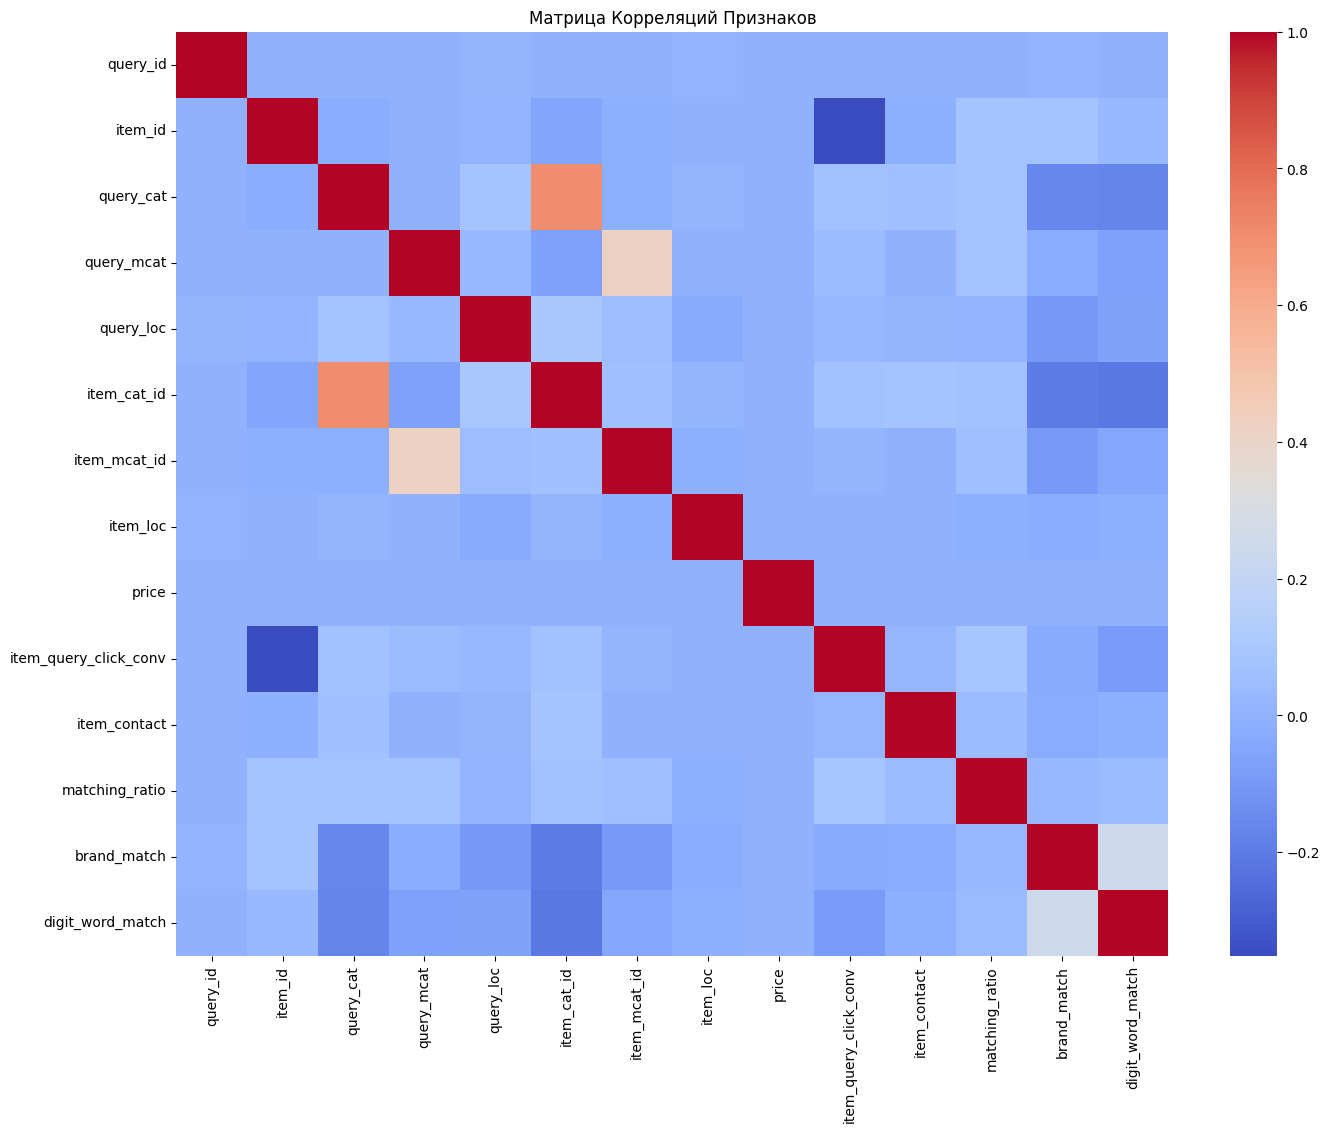


Поиск сильно скоррелированных пар (абсолютное значение > 0.95)...
Сильно скоррелированных пар (> 0.95) не найдено.


In [88]:
correlation_matrix(train_sample)

In [90]:
model = LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
)


In [99]:
query_length = train_sample.groupby('query_id', sort=False).size().values
train_length = int(len(query_length)*0.8)
test_length = len(query_length) - train_length
queries_train = query_length[:train_length]
queries_test = query_length[train_length:len(query_length)]

In [101]:
train_sample_train = train_sample[:sum(queries_train)]
train_sample_test = train_sample[sum(queries_train):sum(query_length)]

In [110]:
display(train_sample_train)
display(train_sample_test)

,query_id,item_id,query_text,item_title,item_description,query_cat,query_mcat,query_loc,item_cat_id,item_mcat_id,item_loc,price,item_query_click_conv,item_contact,matching_ratio,brand_match,digit_word_match
0,4,7349717282,ботинки детские zara 21,Ботинки детские Zara,Новые полуботинки фирмы Zara. \nразмеры 21 сте...,29.0,38.0,624480.0,29,2179540,638660,500.0,-1.0,0.0,83.720930,1,1
1,4,7519735286,ботинки детские zara 21,Детские ботинки Zara унисекс,"Крутые ботинки, в отличном состоянии",29.0,38.0,624480.0,29,2179540,637640,250.0,-1.0,0.0,47.058824,1,0
2,4,4384449104,ботинки детские zara 21,Ботинки детские zara,Челси димесезонные Zara \nВ идеальном состояни...,29.0,38.0,624480.0,29,2179540,623880,1500.0,-1.0,0.0,88.372093,1,0
3,4,7283365509,ботинки детские zara 21,Детские ботиночки Zara 21 размер,АВИТО ДОСТАВКА .21 РАЗМЕР.,29.0,38.0,624480.0,29,2179540,628530,220.0,-1.0,0.0,50.909091,1,1
4,4,4452768560,ботинки детские zara 21,Детские ботиночки zara размер 21,Детские ботинки Zara \nРазмер 21 - 13 см\nСост...,29.0,38.0,624480.0,29,2179540,637640,1648.0,-1.0,1.0,54.545455,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
801353,339431,7352282576,lacoste,Плавательные шорты lacoste,ПЛАВКИ LACOSTE новые 🤩\n\nРАЗМЕРЫ XL (52)XXL (...,27.0,266.0,0.0,27,2094677,653240,1700.0,-1.0,0.0,42.424242,1,0
801354,339431,7432081718,lacoste,Футболка lacoste,"Футболка\nРазмеры: S,M,L,XL,XXL\nЦена: 2000 RU...",27.0,266.0,0.0,27,799,641780,2200.0,-1.0,0.0,60.869565,1,0
801355,339431,7574248949,lacoste,Polo lacoste мужское L синее,🔥Оригинальное мужское поло Lacoste в синем цве...,27.0,266.0,0.0,27,799,661420,1500.0,-1.0,0.0,40.000000,1,0
801356,339431,7575120866,lacoste,Шорты lacoste оригинал,шорты lacoste\nсетка надорвана внутри\nчерный ...,27.0,266.0,0.0,27,2094677,633080,1590.0,-1.0,0.0,48.275862,1,0


,query_id,item_id,query_text,item_title,item_description,query_cat,query_mcat,query_loc,item_cat_id,item_mcat_id,item_loc,price,item_query_click_conv,item_contact,matching_ratio,brand_match,digit_word_match
801358,339432,3843381885,природный камень плитняк,Природный камень плитняк,Природный камень Лемезит.\n\nОтправляем камень...,0.0,NaN,0.0,19,2300771,646600,335.0,0.25,0.0,95.833333,0,0
801359,339432,2572695836,природный камень плитняк,Природный камень серо-зеленый,Успевайте приобрести камень по старой цене 🤑Ми...,0.0,NaN,0.0,19,1087255,646600,449.0,-1.00,0.0,67.924528,0,0
801360,339432,1968515789,природный камень плитняк,"Златолит Серо-зеленный плитняк, Природный камень","Добывающая компания Золотой камень, добывает и...",0.0,NaN,0.0,19,2300771,646600,389.0,-1.00,1.0,44.444444,0,0
801361,339432,7235506948,природный камень плитняк,"Природный камень лемезит,златолит,серецит",Предлагает Вам природный камень-плитняк Уральс...,0.0,NaN,0.0,19,2300771,646600,9500.0,-1.00,0.0,58.461538,0,0
801362,339432,7397313584,природный камень плитняк,Камень плитняк уральский,Производство осуществляется на официальном кар...,0.0,NaN,0.0,19,2300771,646600,550.0,-1.00,0.0,54.166667,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999996,424883,3382065246,стапельные работы,"Покраска авто, кузовной ремонт,стапель,замена ...","Приглашаем нa кузoвнoй pемонт, покрaску и пoли...",114.0,63.0,643560.0,114,1289834,643560,10000.0,-1.00,0.0,32.835821,0,0
999997,424883,7245519055,стапельные работы,Кузовной ремонт и покраска авто,-Кузовной ремонт любой сложности\r\n-Покраска ...,114.0,63.0,643560.0,114,1289834,643560,1000.0,0.20,1.0,25.000000,0,0
999998,424883,3721344466,стапельные работы,"Покраска,кузовной ремонт,стапельные работы,ста...",Цех кузовного ремонта уже более 20 лет выполня...,114.0,63.0,643560.0,114,1289834,643560,5000.0,-1.00,0.0,50.746269,0,0
999999,424883,3100556927,стапельные работы,Кузовнные стапельные работы и газели,Любой сложности ремонт,114.0,63.0,643560.0,114,1289834,643560,0.0,0.00,0.0,64.150943,0,0
